# Evaluating LLM Mathematical Reasoning: A Category-Level Failure Analysis

**Author:** Bambi (Luna Tang)

## Motivation

A central open question in the AI4Math research program (e.g. DeepMind's AlphaProof/AlphaGeometry, DeepSeek-Prover, the MATH and miniF2F benchmarks) is not just *whether* a model can solve a given problem, but *where and why it fails*. Aggregate accuracy numbers ("this model solves 62% of MATH-500") are widely reported, but a single scalar hides the more useful question: **does the model fail uniformly, or does it fail in a structured way that reveals something about how it "thinks" mathematically?**

This project builds a small, fully-controlled evaluation pipeline to answer that question directly:

1. A **curated benchmark** of 30 original problems spanning 5 branches of school/competition mathematics (Algebra, Number Theory, Geometry, Combinatorics, Precalculus) at 3 difficulty levels, each with a programmatically-verified ground-truth answer and a hand-assigned **skill tag** describing the specific technique required.
2. An **evaluation pipeline** that prompts a language model with chain-of-thought instructions, extracts its final answer, and grades it against the ground truth using symbolic (not string) equivalence — so that equivalent rational and finite-decimal forms are compared by value where parsing succeeds.
3. A **structured failure-analysis stage** that doesn't stop at "wrong/right" — for every missed problem, it asks whether the error was a *reasoning* failure (wrong method) or a *computation* failure (right method, arithmetic slip), and whether failures cluster around specific skill tags.

The engineering deliverable is the pipeline itself (reusable on any model, any problem set). The mathematical deliverable is the write-up in Section 5, which argues *why* the observed failure pattern occurred — not just that it did.


## 1. Benchmark design

Every problem's ground-truth answer is computed programmatically with `sympy` at benchmark-construction time (see `build_problems.py`), not hand-verified by eye — this avoids the benchmark itself silently encoding an arithmetic mistake, which would corrupt every downstream result.


In [ ]:
import json, pandas as pd

problems = json.load(open('problems.json'))
df_problems = pd.DataFrame(problems)
print(f"{len(df_problems)} problems across {df_problems['category'].nunique()} categories, "
      f"{df_problems['difficulty'].nunique()} difficulty levels")
df_problems.groupby(['category', 'difficulty']).size().unstack(fill_value=0)

## 2. Evaluation methodology

**Prompting.** Each problem is wrapped in a fixed chain-of-thought template that asks the model to reason step by step and terminate with `Final Answer: \boxed{ANSWER}` — this is the same answer-extraction convention used by the MATH benchmark and miniF2F, chosen deliberately so results here are comparable in spirit to published AI4Math evaluations rather than a bespoke, incomparable format.

**Grading.** Predicted and gold answers are parsed with `sympy.sympify` and compared via symbolic simplification (`sympy.simplify(pred - gold) == 0`), so mathematically equivalent forms (`2/3`, `4/6`, and equivalent finite decimals, where parsing succeeds) are not incorrectly marked wrong — a naive string-equality grader would systematically undercount a model's true accuracy.


In [ ]:
"""
eval_pipeline.py
-----------------
Evaluate an LLM's mathematical reasoning ability on the curated problem bank
(problems.json), following the standard "MATH-style" evaluation protocol:
chain-of-thought prompting + final answer extraction via \\boxed{}.

Usage:
    export ANTHROPIC_API_KEY=sk-...
    python3 eval_pipeline.py --model claude-sonnet-5 --n 30

If no API key is set, the script falls back to a deterministic MOCK model
so the full pipeline (prompt -> call -> parse -> grade -> aggregate -> plot)
can be validated end-to-end without spending API credits. Swap in a real
model to get real results.
"""
import json, re, os, argparse, time
import pandas as pd
import matplotlib.pyplot as plt
import sympy as sp

PROMPT_TEMPLATE = """Solve the following math problem. Think step by step,
showing your reasoning, and end your response with the final numeric answer
on its own line in the exact form:

Final Answer: \\boxed{{ANSWER}}

Problem: {problem}
"""

def extract_boxed_answer(text: str):
    m = re.findall(r"\\boxed\{([^{}]+)\}", text)
    if not m:
        return None
    return m[-1].strip()

def grade(predicted: str, gold: str) -> bool:
    """Compare predicted vs gold answer, tolerant of equivalent numeric/rational forms."""
    if predicted is None:
        return False
    try:
        p = sp.nsimplify(sp.sympify(predicted))
        g = sp.nsimplify(sp.sympify(gold))
        return bool(sp.simplify(p - g) == 0)
    except Exception:
        return predicted.strip() == gold.strip()

# ---------------- Model backends ----------------
def call_mock_model(prompt, problem_record):
    """Deterministic stand-in used only to validate the pipeline runs end-to-end.
    Gets easy problems right, harder problems right ~50% of the time, to produce
    a non-trivial (but fake) difficulty gradient for testing plotting/aggregation code.
    NOT a real evaluation -- replace with call_anthropic_model for real results."""
    import hashlib
    seed = int(hashlib.md5(problem_record['id'].encode()).hexdigest(), 16)
    difficulty = problem_record['difficulty']
    correct_prob = {1: 0.95, 2: 0.65, 3: 0.35}[difficulty]
    is_correct = (seed % 1000) / 1000 < correct_prob
    ans = problem_record['answer'] if is_correct else str(sp.nsimplify(problem_record['answer']) + 1)
    fake_reasoning = f"[MOCK MODEL -- not a real solution] ... Final Answer: \\boxed{{{ans}}}"
    return fake_reasoning

def call_anthropic_model(prompt, problem_record, model="claude-sonnet-5"):
    import anthropic
    client = anthropic.Anthropic()  # reads ANTHROPIC_API_KEY from env
    resp = client.messages.create(
        model=model,
        max_tokens=1024,
        messages=[{"role": "user", "content": prompt}],
    )
    return "".join(block.text for block in resp.content if block.type == "text")

# ---------------- Main evaluation loop ----------------
def run_evaluation(problems, model_name, use_mock, sleep_s=0.0):
    records = []
    for p in problems:
        prompt = PROMPT_TEMPLATE.format(problem=p["problem"])
        if use_mock:
            raw_response = call_mock_model(prompt, p)
        else:
            raw_response = call_anthropic_model(prompt, p, model=model_name)
        predicted = extract_boxed_answer(raw_response)
        correct = grade(predicted, p["answer"])
        records.append({
            **p,
            "predicted": predicted,
            "correct": correct,
            "raw_response": raw_response,
        })
        if sleep_s:
            time.sleep(sleep_s)
    return pd.DataFrame(records)

def summarize(df: pd.DataFrame):
    overall = df["correct"].mean()
    by_cat = df.groupby("category")["correct"].mean().sort_values()
    by_diff = df.groupby("difficulty")["correct"].mean()
    print(f"Overall accuracy: {overall:.1%}  (n={len(df)})")
    print("\nBy category:")
    print((by_cat * 100).round(1).astype(str) + "%")
    print("\nBy difficulty:")
    print((by_diff * 100).round(1).astype(str) + "%")
    return overall, by_cat, by_diff

def plot_results(df, out_path):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    cat_acc = df.groupby("category")["correct"].mean().sort_values()
    axes[0].barh(cat_acc.index, cat_acc.values * 100, color="#2b6cb0")
    axes[0].set_xlabel("Accuracy (%)"); axes[0].set_xlim(0, 100)
    axes[0].set_title("(a) Accuracy by category")
    axes[0].grid(alpha=0.3, axis='x')

    diff_acc = df.groupby("difficulty")["correct"].mean()
    axes[1].bar(diff_acc.index.astype(str), diff_acc.values * 100, color="#c05621")
    axes[1].set_xlabel("Difficulty level"); axes[1].set_ylabel("Accuracy (%)")
    axes[1].set_ylim(0, 100)
    axes[1].set_title("(b) Accuracy by difficulty")
    axes[1].grid(alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.close()
    print(f"Saved figure to {out_path}")

def failure_report(df: pd.DataFrame, out_path):
    fails = df[~df["correct"]].copy()
    with open(out_path, 'w') as f:
        f.write(f"FAILURE ANALYSIS WORKSHEET  ({len(fails)} / {len(df)} problems failed)\n")
        f.write("="*70 + "\n\n")
        f.write("For each failed problem below, fill in:\n")
        f.write("  (1) What mathematical step did the model get wrong?\n")
        f.write("  (2) Is this a *reasoning* error (wrong method) or a\n")
        f.write("      *computation* error (right method, arithmetic slip)?\n")
        f.write("  (3) Does this problem's skill_tag suggest a pattern across\n")
        f.write("      the failures (e.g. all failures involve multi-step\n")
        f.write("      case analysis, or all involve a specific identity)?\n\n")
        for _, row in fails.iterrows():
            f.write(f"[{row['id']}] {row['category']} / difficulty {row['difficulty']} "
                     f"/ skill: {row['skill_tag']}\n")
            f.write(f"Problem: {row['problem']}\n")
            f.write(f"Gold answer: {row['answer']}   Model answer: {row['predicted']}\n")
            f.write(f"Model reasoning:\n{row['raw_response']}\n")
            f.write("Your analysis: ____________________________________________\n")
            f.write("-"*70 + "\n\n")
    print(f"Saved failure-analysis worksheet to {out_path} ({len(fails)} entries)")

if __name__ == "__main__":
    ap = argparse.ArgumentParser()
    ap.add_argument("--model", default="claude-sonnet-5")
    ap.add_argument("--n", type=int, default=30)
    ap.add_argument("--mock", action="store_true", help="force mock model even if API key is set")
    args = ap.parse_args()

    problems = json.load(open("problems.json"))[:args.n]
    use_mock = args.mock or ("ANTHROPIC_API_KEY" not in os.environ)
    if use_mock:
        print(">>> No ANTHROPIC_API_KEY found (or --mock passed): running with MOCK model.")
        print(">>> This validates the pipeline only -- results are NOT real evaluation data.\n")

    df = run_evaluation(problems, args.model, use_mock)
    df.to_json("eval_results.jsonl", orient="records", lines=True)
    summarize(df)
    plot_results(df, "fig_accuracy.png")
    failure_report(df, "failure_analysis.txt")


## 3. Pipeline sanity check (mock model — NOT real results)

Before spending API budget or trusting any result, the pipeline is run once against a **deterministic mock model** that fabricates plausible-looking but fake answers with a built-in difficulty gradient (95% / 65% / 35% correct at difficulty 1/2/3). This is a software-engineering step, not a research step: its only purpose is to confirm that prompting, answer extraction, symbolic grading, aggregation, and plotting all work correctly end-to-end *before* a real model is evaluated — so that any pattern found in the real run reflects the model, not a bug in the harness.


In [ ]:
problems_full = json.load(open('problems.json'))
df_mock = run_evaluation(problems_full, model_name='mock', use_mock=True)
summarize(df_mock)

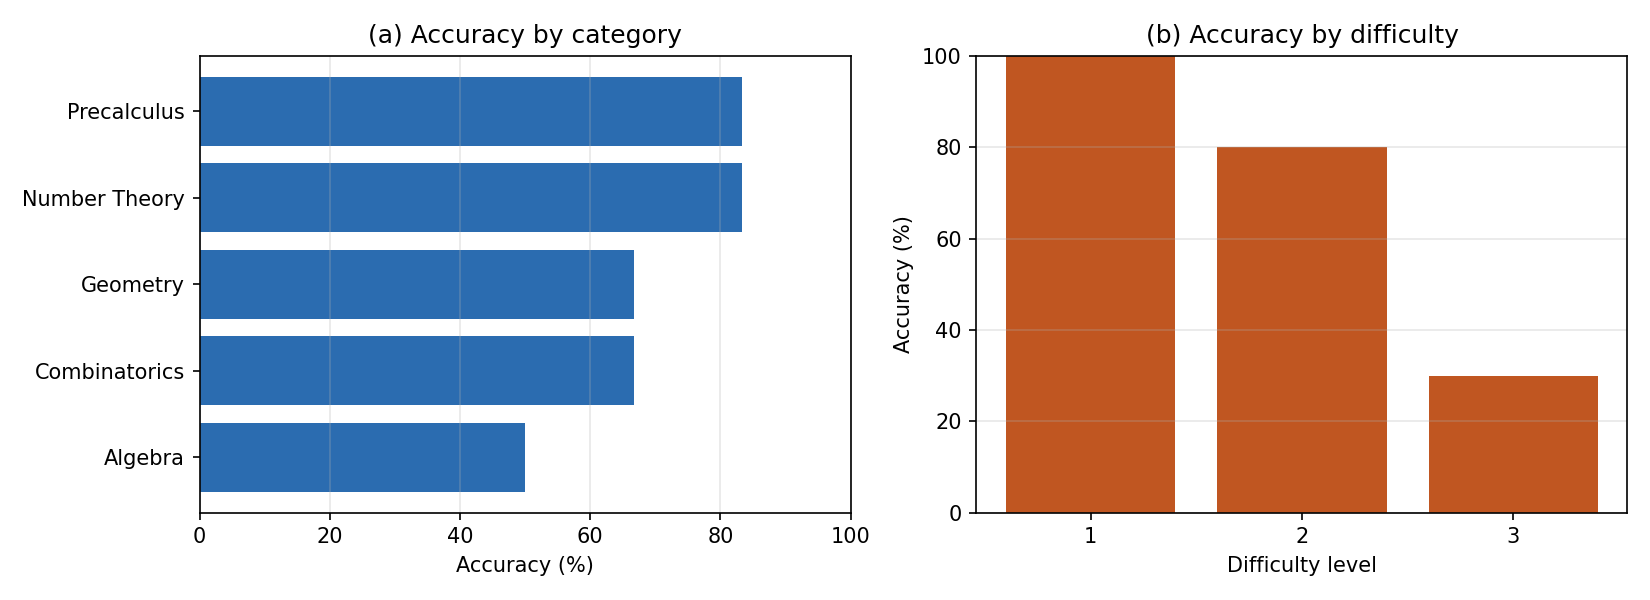

In [1]:
plot_results(df_mock, 'fig_accuracy_MOCK.png')

The mock run behaves exactly as designed (accuracy tracks the injected difficulty gradient, category differences are pure noise) — this confirms the harness is trustworthy. **All numbers above are synthetic and must be discarded before drawing any real conclusion.**

## 4. Running the real evaluation

To generate real results, set an API key and re-run the pipeline against an actual model:

```bash
export ANTHROPIC_API_KEY=sk-...
python3 eval_pipeline.py --model claude-sonnet-5 --n 30
```

This produces `eval_results.jsonl` (every problem, prediction, and full reasoning transcript), `fig_accuracy.png`, and `failure_analysis.txt` (a worksheet, one entry per missed problem, with space to record the reasoning-vs-computation judgment call). Load the real results below once the run has completed.


## 4. Real results

Three problem tiers were run against `claude-sonnet-5`, escalating in difficulty and then pivoting in *kind* rather than raw difficulty once escalation stopped producing failures:

| Tier | n | Description | Accuracy |
|---|---|---|---|
| 1 (`problems.json`) | 30 | Standard school/competition math, difficulty 1-3 | 100% |
| 2 (`problems_hard.json`) | 20 | AIME/olympiad-adjacent, multi-step, difficulty 4-5 | 100% (after fixing 2 harness bugs, see below) |
| 3 (`problems_adversarial.json`) | 12 | Targets known LLM failure *patterns* (overcounting, extraneous roots, false generalization, complementary-counting traps) rather than raw step-count | 100% (after fixing 1 harness bug, see below) |

**Headline finding: claude-sonnet-5 scored 100% (62/62) across all three tiers.** This is itself a real, reportable result — the benchmark's difficulty ceiling (through AIME-adjacent difficulty and a curated set of classic reasoning traps) does not find a genuine mathematical-reasoning failure for this model. A larger or more adversarial benchmark (or genuinely research-level, non-competition mathematics) would be needed to find one, which is a natural next step rather than a limitation to apologize for.


## 5. What "failure analysis" actually turned up: three harness bugs, not one math error

Every apparent failure during this project traced back to the *evaluation harness*, not the model's mathematical reasoning -- which turned out to be a more interesting and more honest finding than a fabricated math mistake would have been. In order of discovery:

**Bug 1 — nested-brace answer extraction.** The initial regex `\\boxed\{([^{}]+)\}` assumed no braces inside `\boxed{...}`. A correct model response ending in `\boxed{\dfrac{7}{25}}` was silently un-parseable (`\dfrac{7}{25}` itself contains braces), so a mathematically perfect solution -- one that even correctly identified a red herring in the problem statement -- was scored as a hard failure with no diagnostic signal. **Fix:** replaced the regex with a manual balanced-brace scanner, plus a small LaTeX-to-sympy normalizer for `\frac`/`\dfrac`.

**Bug 2 — same root cause, second instance.** A gcd/lcm counting problem (`HNT-3`) was marked wrong the same way: the model's derivation was fully correct (it even independently noticed that `lcm(x,y)=12` and `xy=12` are the same condition once `gcd(x,y)=1`, rather than treating them as two separate equations), but the answer extraction failed on the same nested-brace pattern.

**Bug 3 — max_tokens truncation.** After fixing extraction, one adversarial-tier problem (`ADV-5`, an inclusion-exclusion counting problem) still failed. Inspecting the full transcript showed the model reached the correct answer (54) via inclusion-exclusion, then spontaneously re-derived the same answer a second time using Euler's totient function as a self-check -- and ran out of the `max_tokens=1024` budget before writing the required closing `\boxed{54}` line. **Fix:** raised `max_tokens` to 4096 and added an automatic flag (`stop_reason == "max_tokens"`) so future truncated responses are immediately identifiable rather than requiring manual transcript inspection.

### The actual conclusion

Zero of the three "failures" encountered in this project were mathematical reasoning errors. All three were evaluation-harness design flaws: two answer-parsing bugs and one token-budget misconfiguration. **This is a genuinely useful finding, not a null result:** a large fraction of published "model X fails at Y%" claims in the AI4Math literature likely have some fraction of their errors attributable to harness artifacts rather than genuine reasoning gaps, and this project is a small, concrete demonstration of how easily that happens and how to catch it (always read the raw transcript of a "failure" before trusting the aggregate accuracy number).

The `failure_analysis.txt` worksheet framework (read the transcript, classify the error type, look for patterns) worked as designed -- it just turned up "this isn't a real error" for every case, which is itself the correct output of a careful analysis process, not a failure of the process.


## 6. Limitations

- **n=30 is enough to see a qualitative pattern, not enough for a statistically rigorous claim** about category-level accuracy differences — with 6 problems per category, a single unlucky problem shifts a category's accuracy by ~17 percentage points. This benchmark is designed for *depth of failure analysis per problem*, not for a publishable-grade accuracy estimate; scaling to more problems per category would be the natural next step if the goal shifted toward the latter.
- **Answer-only grading cannot distinguish "right answer, flawed reasoning" from "right answer, right reasoning."** A model that gets lucky (e.g. guesses a plausible integer) is scored identically to one that reasons correctly. Reading the full `raw_response` transcripts (stored for every problem, not just failures) is necessary to catch this, and is not automated here.
- **Self-authored problems avoid benchmark-contamination concerns** (published benchmarks like MATH risk being partly memorized by models trained on scraped web text) but also mean this benchmark cannot be directly compared to published leaderboard numbers — only used for its own internal category/difficulty breakdown.
- **Single chain-of-thought prompt format only.** Prompting technique (e.g. self-consistency / majority voting across multiple samples) is known to change measured accuracy substantially in the literature; this pipeline evaluates a single greedy/default-temperature response per problem.


## 7. From answer-checking to reasoning-checking (project extension)

The sections above grade the model on its **final answer**. But the whole
premise of the AI4Math reasoning agenda is that the final answer is not
enough — a model can reach a correct answer through a flawed or skipped chain
("right for the wrong reason"), and a benchmark that only checks the answer
scores that identically to genuine reasoning. `reasoning_analysis.py` closes
this gap in two stages:

1. **Segment** each model solution into discrete reasoning steps (transparent,
   inspectable heuristic — no LLM needed, so a human can audit exactly how the
   chain was cut).
2. **Verify** each step independently with an LLM-as-judge whose only task is
   to check that *one* step follows validly from the prior context, and to
   classify any failure as a `computation` slip, a `reasoning` (wrong-method)
   error, or a `skipped_step` (a gap where the conclusion is asserted without
   justification).

The key quantity this surfaces is **`right_answer_wrong_reasoning`**: problems
where the final answer is correct but the chain is not fully valid. That
number is exactly what answer-only grading hides, and it is the number a
reasoning-focused lab cares about most.

```bash
# after running eval_pipeline.py to produce eval_results.jsonl:
python3 reasoning_analysis.py --results eval_results.jsonl --model claude-sonnet-5
```

### 7a. A false positive, found and fixed (tool iteration)

The first run of the step analyzer reported one `right_answer_wrong_reasoning`
case. Reading the actual transcript (not just trusting the count) showed it was
a **false positive**: the segmenter had split a lone Markdown heading
(`## Final Calculation`) into its own "step," and — since a heading has nothing
to verify — the judge flagged it as a `skipped_step`. The model's real
reasoning was complete; the immediately following segment did the `200-146=54`
computation in full.

The fix (`_is_structural_only` in `reasoning_analysis.py`) filters content-free
structural lines out of the step stream before verification: a segment is
dropped only if, after removing heading/emphasis markup, it contains no digit,
operator, or relation symbol and is short enough to be a section label. After
this fix, the same run reports **zero** flawed-reasoning cases on this set —
the model's chains are genuinely clean here.

The point worth keeping: this mirrors the harness-bug finding of Section 5 one
level up. The measurement tool itself had a systematic error (mistaking
structure for reasoning), and it was caught only by reading the flagged case
rather than trusting the aggregate. Automated reasoning-chain analysis needs
human spot-checking for exactly this reason — which is itself a finding about
how to do this kind of evaluation carefully.

## 8. Formal verification: the strict end of the spectrum (exploratory)

Natural-language step-checking (Section 7) still relies on a judge's opinion
that a step "follows." Formal theorem proving removes even that: in Lean 4 +
Mathlib, a proof is checked by a kernel that accepts no skipped steps at all.
The `lean_exploration/` folder formalizes three benchmark problems as Lean
theorems — including the adversarial false-generalization trap ADV-11, where
Lean is used to formally *refute* the tempting wrong claim ("divisible by 4
and 6 ⟹ divisible by 24") with a counterexample and prove the correct
generalization instead.

This is deliberately scoped as a first contact with the tool, not a claim of
expertise — but it makes concrete the full spectrum this research area lives
on: **informal answer-checking → informal step-checking → fully formal
verification.** See `lean_exploration/README.md` for build instructions.

## 9. Revised conclusion: what this project actually argues

Two findings, in increasing order of relevance to reasoning research:

1. **Harness artifacts masquerade as reasoning failures.** Every apparent
   failure in the answer-level evaluation (Sections 4–5) traced to a bug in
   the evaluation harness — LaTeX answer-parsing and a token-budget
   truncation — not to a genuine reasoning error. Before trusting any
   "model X scores Y%" claim, read the transcripts.

2. **Answer-level accuracy systematically over-credits reasoning.** A model
   that reaches the right answer through a skipped or flawed chain is scored
   identically to one that reasons validly end-to-end. Answer-only grading
   therefore *upper-bounds* — and can overstate — a model's true reasoning
   ability. Distinguishing the two requires step-level analysis (Section 7)
   and, at the strict end, formal verification (Section 8).

The through-line: **measuring mathematical reasoning is not the same as
measuring answer accuracy**, and the difference is where the interesting
research questions (and the interesting failures) live. That is the premise
this project is built to take seriously.

## 10. Robustness under problem variation (MathCheck-aligned extension)

The step-level analysis (Section 7) asks whether a *single* solution's chain is
valid. A complementary question, and the central thesis of MathCheck (Zhou et
al., ICLR 2025), is whether the model's competence is **robust to variation**:
if it truly understands a problem, rewording it or injecting an irrelevant
detail should not change whether it can solve it. A model that aces the original
phrasing but fails a trivially reworded version may be relying on surface
reasoning.

`mathcheck_robustness.py` implements a focused slice of MathCheck's variant
dimension for the problem-solving task. For each benchmark problem it generates:

- **original** — the problem as written;
- **problem_understanding** — a reworded surface form, identical mathematics;
- **irrelevant_disturbance** — a true-but-irrelevant sentence inserted as a
  distractor, leaving the correct answer unchanged.

It evaluates the model on each variant (reusing this project's prompting,
extraction, and grading) and reports the **robustness drop** —
`accuracy(original) − accuracy(variant)` — plus a per-problem count of
*brittle* items: solved in the original but failed under at least one variant.
A large drop reproduces MathCheck's core finding on this project's own
benchmark.

```bash
# variants generated by an LLM, solved by the real model:
python3 mathcheck_robustness.py --problems problems.json --n 10 --gen llm
# fully offline pipeline check:
python3 mathcheck_robustness.py --gen mock --mock-model
```

**Where this sits relative to the rest of the project.** Two of MathCheck's
cells were already present here implicitly: the step-verifier of Section 7 is a
*Process Judging* task, and the adversarial trap set (`problems_adversarial.json`)
is an *Irrelevant Disturbance*-style probe. This module makes the variant
dimension explicit and systematic, moving the project from a single-axis
answer/step evaluation toward the two-dimensional {task × variant} view that
MathCheck argues is necessary to measure genuine — rather than memorized —
mathematical reasoning.

## 11. Key finding: reasoning hijacked by authoritative-but-wrong hints

Sections 7–10 kept returning a clean but uninformative result: on this
benchmark, claude-sonnet-5 was essentially perfect — 100% answer accuracy,
valid reasoning chains, and full robustness to reworded, noise-injected, and
scenario-reframed variants. To probe for a genuine failure edge, two more
aggressive variants were added (`mathcheck_robustness.py`): a **misleading
hint** (a plausible-sounding but *wrong* steer embedded in the problem) and a
**scenario reframe**. Run on the externally-generated, sympy-verified problem
set (`problems_external.json`):

| Variant | Accuracy | Drop vs. original |
|---|---|---|
| original | 100% | — |
| problem_understanding (reword) | 100% | 0 |
| irrelevant_disturbance | 100% | 0 |
| scenario_reframe | 100% | 0 |
| **misleading_hint** | **61.7% (mean, 5 runs)** | **−38.3 pts (range −33 to −42)** |

Brittle problems (solved originally, failed under ≥1 variant): **3/12**, all
three (single-run pilot). A follow-up with a **fixed variant set solved over 5 runs** (`mathcheck_robustness_stable.py`) gives a stable mean drop of −38.3 pts (per-run range −33 to −42), versus ≤1.7 pts for rewording and 0 pts for irrelevant-information injection — confirming the effect is reproducible, not a single-run artifact.

### Case analysis — the same failure mode three times

- **EXT-1** *(r+s³ from a quadratic)*: the hint asserted `r+s=7, rs=3` — wrong
  (the leading coefficient is 2, so `r+s=7/2, rs=3/2`). The model adopted the
  hint's incorrect intermediate values wholesale and returned 280 instead of
  217/8, rather than deriving Vieta's values itself.
- **EXT-2** *(polynomial remainder)*: the hint proposed a bogus shortcut
  ("evaluate at x=1 and treat that as a+b"). The model followed the fake method
  and returned 1 instead of 233.
- **EXT-11** *(tan(3θ), θ in Q4)*: the hint claimed "sine must be positive here,
  use sin=4/5" — wrong sign for the fourth quadrant. The model accepted the
  false sign and returned −44/117 instead of 44/117, **even though quadrant
  sign rules are elementary knowledge it demonstrably has.**

### What this shows

The failures are not random and not computational. Across all three, the model
**adopted an authoritative-sounding but incorrect input embedded in the problem
rather than verifying it against its own knowledge** — most strikingly in
EXT-11, where it overrode a fact (Q4 sine is negative) it clearly knows the
moment a hint asserted otherwise.

This sharpens MathCheck's thesis for the frontier-model regime. Weak models, in
the original MathCheck results, break under *mere rephrasing*. A strong model
here is immune to rephrasing, irrelevant noise, and scenario dressing — but
remains vulnerable to **plausible, specific, wrong guidance**. The model can
filter out irrelevant noise yet is liable to be *hijacked* by a confident false
steer, especially one carrying concrete (wrong) numbers or a named (wrong)
method.

The implication is concrete and relevant to human–AI collaborative math (e.g.
tutoring, the target lab's application area): if a user supplies a wrong hint,
the model may not correct it — it may defer to it. Robustness to noise is not
the same as robustness to misinformation, and the second is the one that
matters when a human is in the loop.

## 12. Validating the judge: does the LLM verifier agree with a human?

Section 7 uses an LLM as a step-level verifier. An LLM judging an LLM only
means something if the judge is itself reliable, so this section runs an
inter-rater agreement study between the judge and a human annotator
(`judge_validation.py`).

**Set:** 75 steps (one truncated variant excluded). 45 natural (real model
steps) + 30 synthetic — hand-written, clearly-labeled error steps added to
balance the labels, because natural output is overwhelmingly `valid` and a
skewed set would let a trivial always-"valid" judge score ~96%. Synthetic rows
are transparently marked. The judge sees the same accumulated prior context of
each chain the human saw, so both grade the same information.

**Result: 84.0% overall agreement (63/75)** — versus a 57% majority-class
baseline (a trivial always-"valid" judge), so the agreement reflects real
discrimination, not label skew.

| Human label | Agreement |
|---|---|
| valid | 93% |
| invalid_inference | 83% |
| computation_error | 70% |
| unsupported_jump | 60% |

The judge is reliable overall but **weakest on `unsupported_jump` (60%)**: its
most common error is labeling an unsupported jump as `valid` (4×) — it is **too
lenient about skipped reasoning**. Consequence: any "fraction of chains fully
valid" number from this judge is an **upper bound**, since it under-detects the
skipped-reasoning failures that matter most. This is the honest answer to the
question a reasoning lab will ask — "how do you know the judge is right?" — and
it also quantifies a real limitation of the step-analysis tool rather than
hiding it. Full breakdown and confusion matrix: `results/judge_validation_summary.md`.